In [1]:
from common_functions import single_wavelet
import numpy as np
import matplotlib.colors as colors
from pyasassn.client import SkyPatrolClient
import matplotlib.pyplot as plt

In [2]:
tmin = 2458485
tmax = 2460311

# This notebook is meant to demonstrate how one would make a single object wavelet transform given a specific ASAS-SN ID

In [3]:
def plotter(wavelet):
    fig, ax = plt.subplots(figsize=(10,6))
    
    # Axis ticks and labels
    periods = np.arange(1, 30, 0.2275)
    ff = 1/periods
    
    tixs_xaxis = [2458604.5, 2458849.5, 2459214.5, 2459579.5, 2459944.5, 2460309.5]
    labels_xaxis = ["5/1/2019", "1/1/2020", "1/1/2021", "1/1/2022", "1/1/2023", "1/1/2024"]
    
    tixs_yaxisfreq = [ff[0], ff[4], ff[10], ff[40], ff[120]]
    labels_freqs = [1.0, 0.52, 0.31, 0.09, 0.04]
    
    tixs_yaxisperi = [periods[0], periods[4], periods[10], periods[40], periods[120]]
    labels_time = [1.0, 1.91, 3.27, 10.1, 28.3]
    
    ax.imshow(wavelet, aspect='auto', extent=(tmin, tmax, np.min(ff), np.max(ff)))
    ax.set_xlabel("Time", weight='bold')
    ax.set_ylabel("Frequency (1/day)", weight='bold')
    ax.set_xticks(ticks = tixs_xaxis, labels=labels_xaxis, weight='bold')
    ax.set_yticks(ticks = tixs_yaxisfreq, labels=labels_freqs, weight='bold')
    
    ax2 = ax.twinx()
    ax2.imshow(wavelet, aspect='auto', extent=(tmin, tmax, np.min(ff), np.max(ff)))
    ax2.set_yticks(ticks = ax.get_yticks(), labels=labels_time, weight='bold')
    ax2.set_ylabel("Period (days)", weight='bold')

In [4]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [5]:
def pipeline(objid):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    wavelet = single_wavelet(savedlc, savedlc.data.flux)
    plotter(wavelet)

Pulled 1 of 1


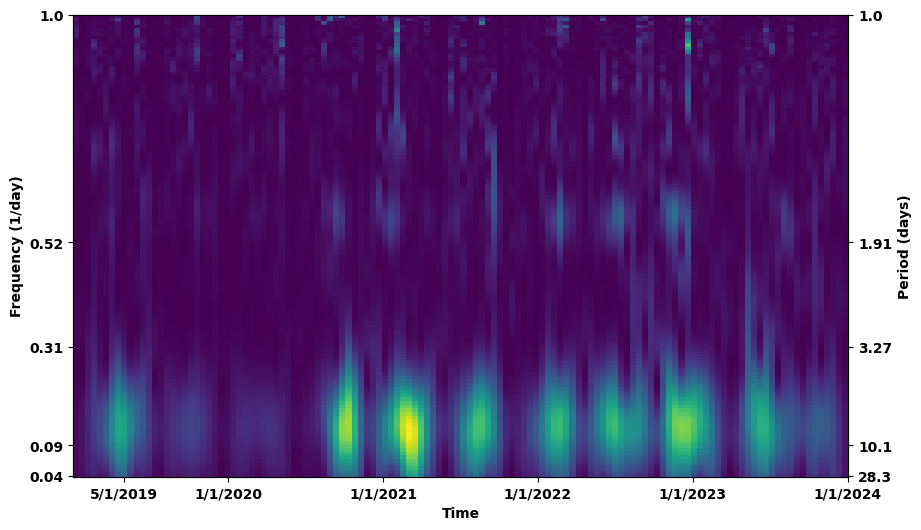

In [6]:
pipeline(463856975202)